In [20]:
import numpy as np
import matplotlib.pyplot as plt

Converged after 6403 iterations


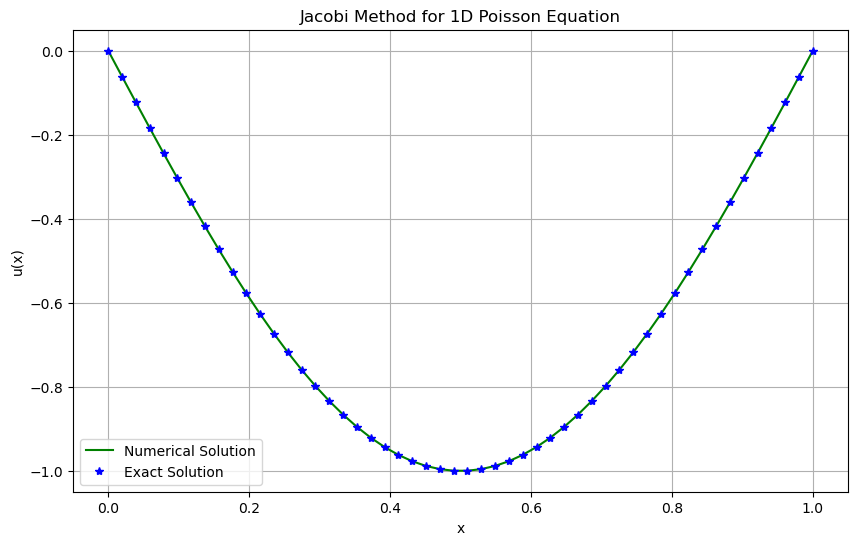

In [ ]:
def create_poisson_matrix(n):
    h = 1.0 / (n + 1)
    main_diag = 2.0 * np.ones(n) / h**2
    off_diag = -1.0 * np.ones(n-1) / h**2
    A = np.diag(main_diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)
    return A, h

def jacobi_poisson(f, n, max_iterations=10000, tolerance=1e-8):
    h = 1.0 / (n + 1)
    x = np.linspace(0, 1, n + 2) 
    x_interior = x[1:-1]
    A, h_val = create_poisson_matrix(n)
    b = f(x_interior)
    u = np.zeros(n + 2)
    u_new = np.zeros(n + 2)
    errors = []
    
    for iteration in range(max_iterations):
        for i in range(1, n + 1):
            u_new[i] = 0.5 * (u[i-1] + u[i+1] + h_val**2 * b[i-1])
        error = np.max(np.abs(u_new - u))
        errors.append(error)
        if error < tolerance:
            print(f"Converged after {iteration + 1} iterations")
            return u_new, x, iteration + 1, errors
        u = u_new.copy()
    
    print(f"Did not converge after {max_iterations} iterations")
    return u, x, max_iterations, errors

def test_function(x):
    return -np.pi**2 * np.sin(np.pi * x)

u , x , max_iterations, errors = jacobi_poisson(test_function, n=50)
plt.figure(figsize=(10, 6))
plt.plot(x, u, 'g-', label='Numerical Solution')
plt.plot(x, -np.sin(np.pi * x) , 'b*', label='Exact Solution')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Jacobi Method for 1D Poisson Equation')
plt.legend()
plt.grid(True)
plt.show()

        
        
      
    
    